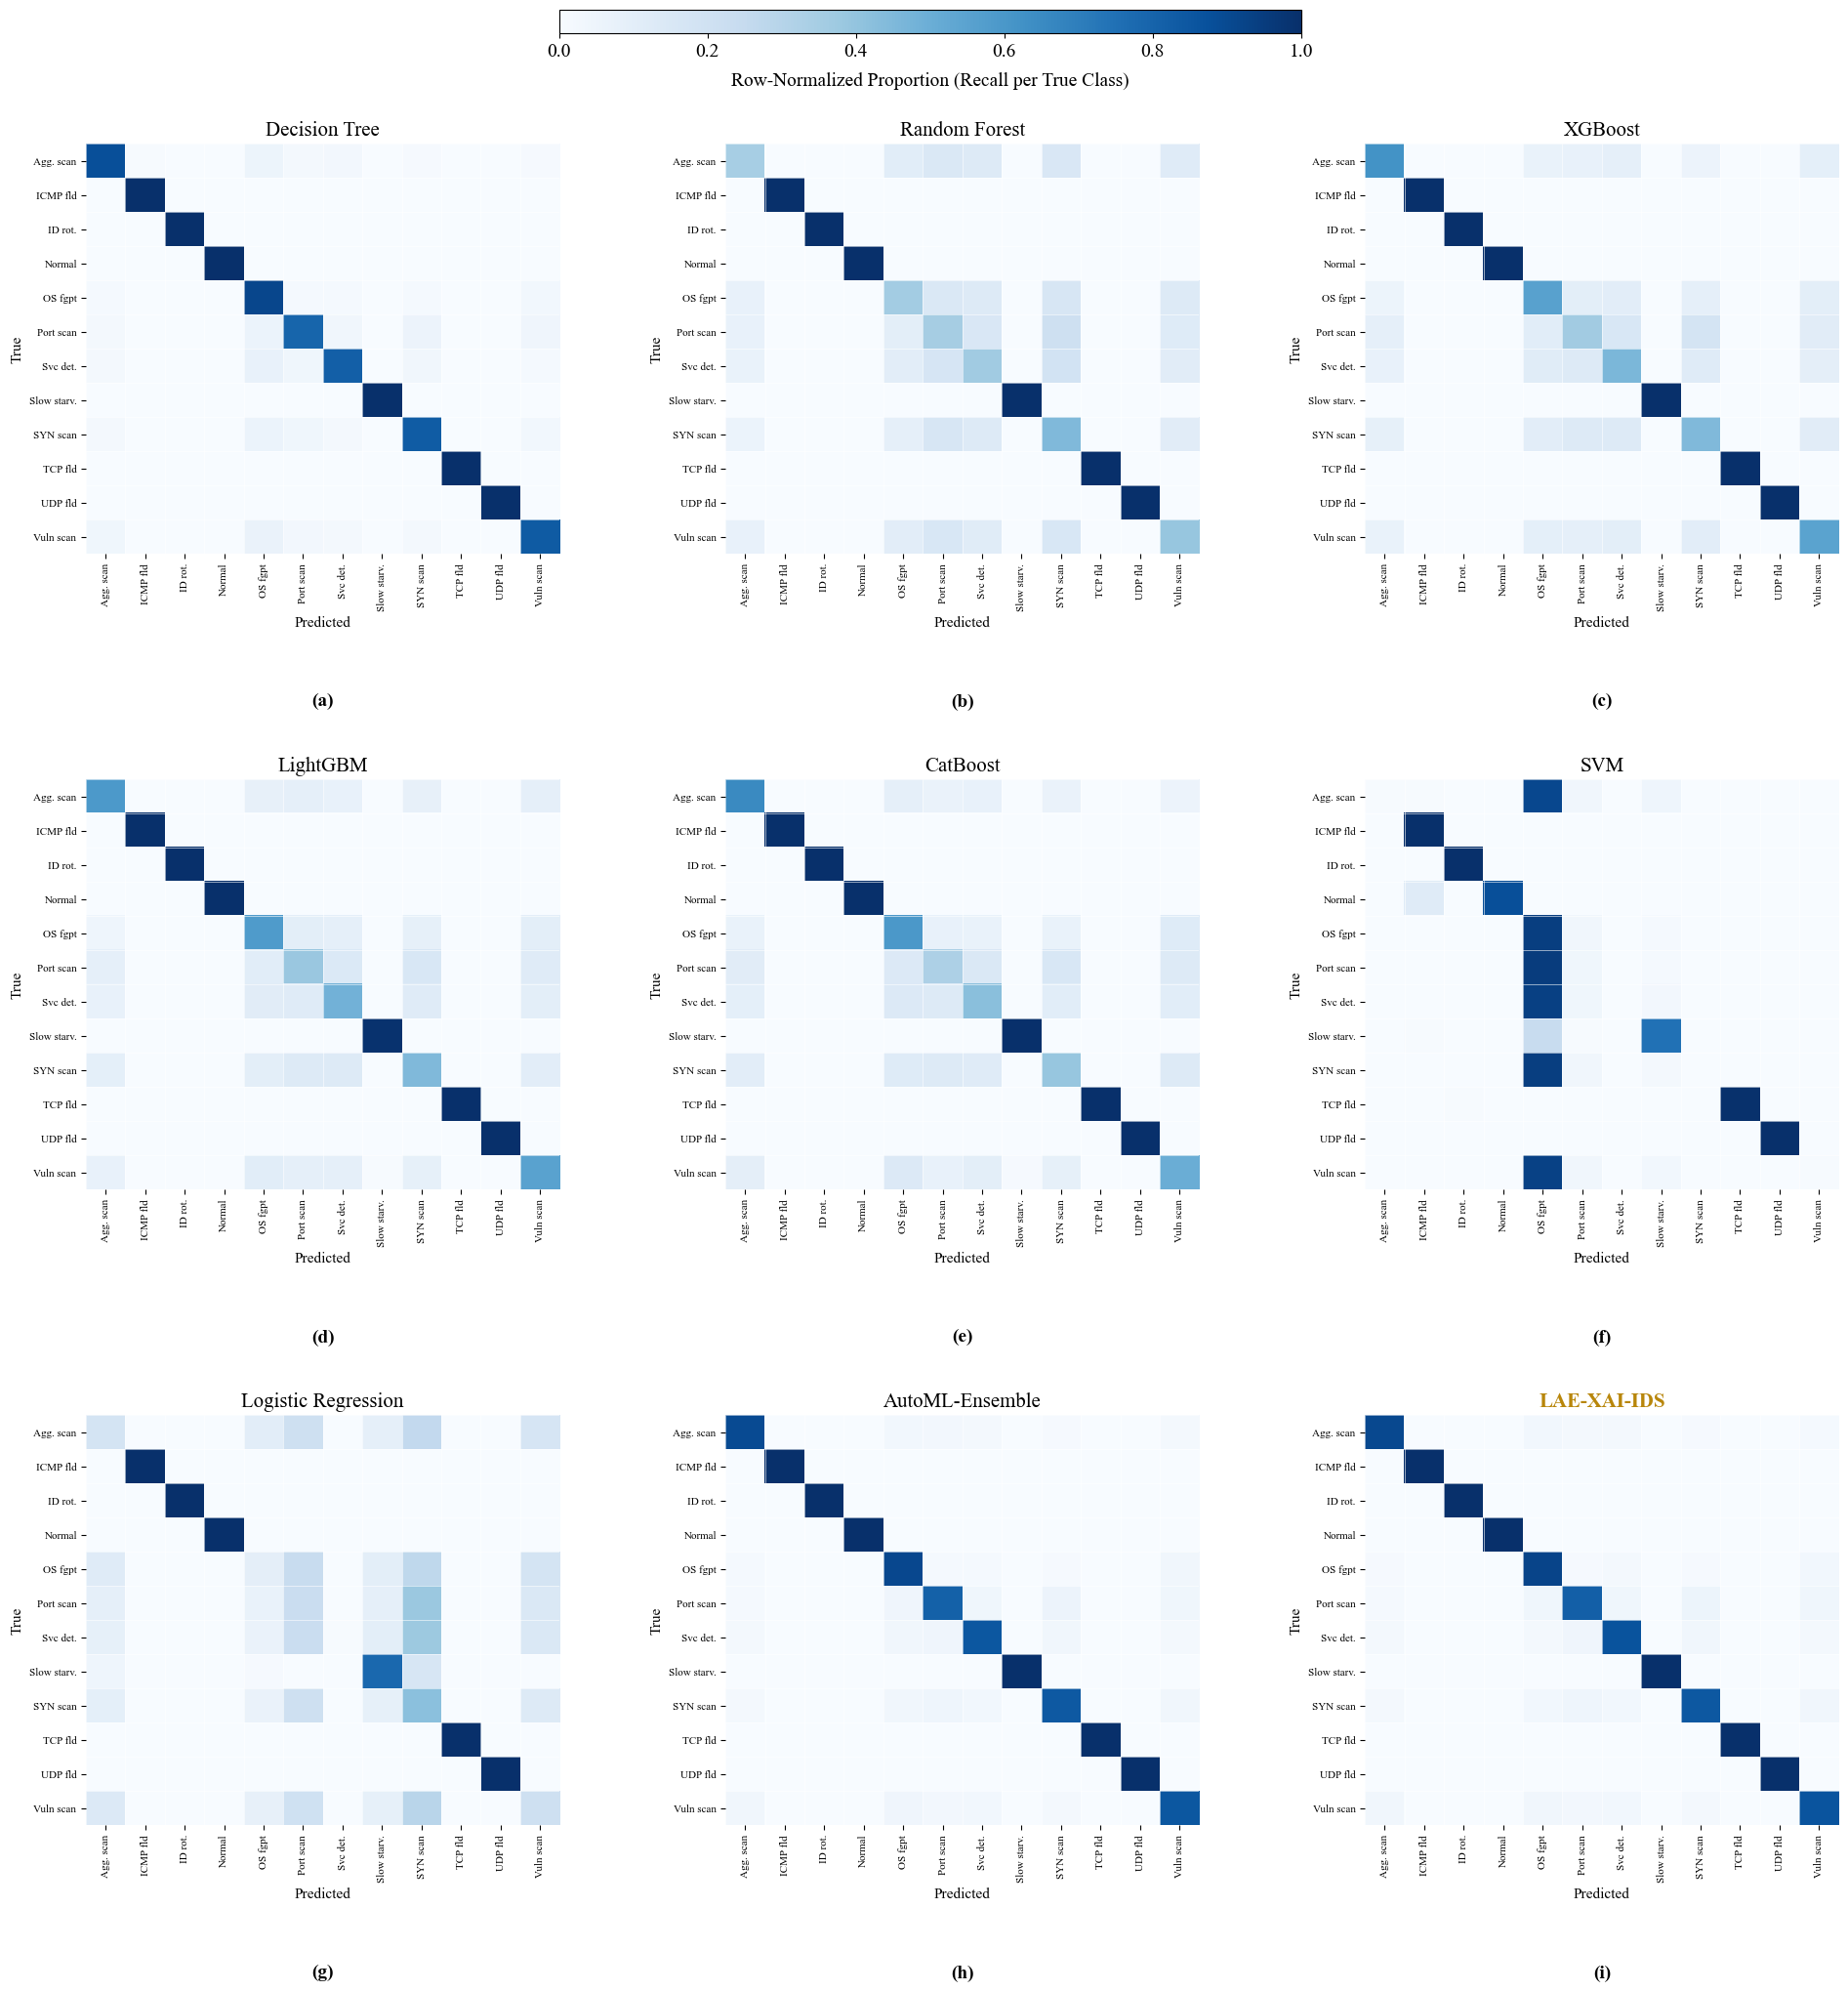

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12, 'axes.titlesize': 14, 'mathtext.fontset': 'stix',
})

class_names = [
    "Aggressive scan", "ICMP flood or fragmentation", "Identity rotation and rotation flood",
    "Normal", "OS fingerprinting", "Port scanning", "Service detection",
    "Slow request starvation", "Stealth SYN scanning", "TCP floods",
    "UDP flood", "Vulnerability scan",
]

confusion_matrices = {
    "Decision Tree": [
        [18053, 85, 0, 0, 1069, 396, 483, 43, 207, 2, 0, 163],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 52423, 0, 0, 0, 0, 0, 0, 10, 0, 1],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [428, 68, 0, 1, 25615, 398, 392, 9, 339, 0, 0, 803],
        [1429, 4, 0, 2, 5150, 67685, 2753, 1, 4718, 8, 0, 3563],
        [1245, 6, 0, 0, 4199, 2262, 47902, 3, 2040, 14, 0, 890],
        [1, 0, 0, 0, 0, 0, 0, 839, 0, 0, 0, 0],
        [2026, 7, 0, 0, 6416, 3999, 2236, 2, 88242, 3, 0, 3254],
        [5, 20, 0, 2, 1, 0, 2, 3, 0, 144173, 0, 3],
        [1, 2, 0, 0, 0, 0, 3, 0, 0, 0, 6489, 0],
        [1781, 12, 0, 1, 2959, 1100, 848, 8, 1034, 21, 0, 38506],
    ],
    "Random Forest": [
        [7123, 23, 0, 0, 2209, 3007, 2627, 50, 3058, 0, 0, 2404],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 2, 52424, 0, 0, 0, 0, 0, 0, 8, 0, 2],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [2093, 45, 0, 1, 10074, 4153, 3550, 48, 4454, 0, 0, 3635],
        [6091, 4, 0, 2, 8340, 29861, 12704, 168, 17690, 0, 0, 10453],
        [4026, 2, 0, 0, 5957, 9763, 21314, 56, 10977, 0, 0, 6466],
        [1, 0, 0, 0, 0, 0, 0, 839, 0, 0, 0, 0],
        [6560, 5, 0, 0, 9309, 17189, 13683, 89, 47622, 0, 0, 11728],
        [0, 25, 3, 2, 0, 0, 0, 3, 0, 144176, 0, 0],
        [0, 4, 0, 0, 2, 0, 0, 0, 0, 0, 6489, 0],
        [3522, 7, 0, 0, 4820, 7101, 5336, 179, 7226, 0, 0, 18079],
    ],
    "XGBoost": [
        [12695, 13, 0, 3, 1434, 1509, 1824, 10, 1143, 1, 0, 1869],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [2, 0, 52424, 0, 0, 0, 0, 0, 0, 10, 0, 0],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [1437, 17, 0, 1, 15593, 2759, 2934, 3, 2501, 0, 0, 2808],
        [7516, 4, 0, 1, 9166, 30988, 13293, 14, 14739, 0, 0, 9592],
        [4465, 2, 0, 2, 6734, 7762, 26908, 2, 7058, 1, 0, 5627],
        [1, 0, 0, 0, 0, 0, 0, 839, 0, 0, 0, 0],
        [8968, 4, 0, 0, 11142, 13479, 13409, 0, 47474, 0, 0, 11709],
        [0, 25, 3, 2, 1, 0, 0, 3, 0, 144175, 0, 0],
        [1, 3, 0, 0, 0, 0, 2, 2, 0, 1, 6485, 1],
        [3142, 5, 0, 2, 4250, 4157, 4526, 7, 4704, 0, 0, 25477],
    ],
    "LightGBM": [
        [12109, 9, 0, 0, 1673, 1803, 1504, 6, 1614, 0, 0, 1783],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 52424, 0, 1, 0, 0, 0, 0, 9, 0, 0],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [1263, 15, 0, 1, 16370, 2799, 2454, 5, 2326, 0, 0, 2820],
        [7587, 3, 0, 1, 9115, 32928, 11996, 182, 13264, 0, 0, 10237],
        [4165, 2, 0, 0, 6588, 6951, 28145, 3, 6957, 0, 0, 5750],
        [1, 0, 0, 0, 0, 3, 0, 833, 1, 0, 0, 2],
        [9930, 4, 0, 0, 10771, 13280, 13609, 197, 47298, 0, 0, 11096],
        [1, 26, 3, 1, 0, 0, 0, 2, 0, 144176, 0, 0],
        [0, 4, 0, 0, 0, 2, 2, 0, 0, 0, 6487, 0],
        [3319, 4, 0, 0, 4913, 4085, 4123, 257, 3909, 0, 0, 25660],
    ],
    "CatBoost": [
        [13406, 20, 0, 1, 1786, 1304, 1470, 66, 1320, 2, 0, 1126],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [2, 0, 52432, 0, 0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [1928, 21, 0, 1, 16664, 2066, 1940, 13, 1936, 0, 0, 3484],
        [9616, 4, 0, 2, 11464, 27990, 12298, 93, 13003, 0, 0, 10843],
        [5341, 3, 0, 0, 7838, 7775, 24897, 150, 6248, 0, 0, 6309],
        [1, 0, 0, 0, 0, 0, 0, 839, 0, 0, 0, 0],
        [11070, 6, 0, 0, 12970, 13795, 12478, 400, 41585, 0, 0, 13881],
        [0, 29, 172, 0, 0, 0, 0, 3, 0, 144005, 0, 0],
        [0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 6489, 0],
        [4369, 5, 0, 1, 6253, 3588, 4641, 429, 3797, 1, 0, 23186],
    ],
    "SVM": [
        [116, 143, 0, 48, 18590, 686, 0, 918, 0, 0, 0, 0],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 3, 52432, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 2, 0, 15, 0, 0, 0, 0, 0, 0, 0, 0],
        [44, 101, 0, 1, 26507, 972, 1, 427, 0, 0, 0, 0],
        [0, 4, 0, 2, 81214, 3071, 0, 1022, 0, 0, 0, 0],
        [0, 11, 0, 51, 54774, 2108, 209, 1408, 0, 0, 0, 0],
        [0, 6, 0, 0, 199, 6, 0, 629, 0, 0, 0, 0],
        [0, 7, 0, 0, 100069, 3706, 0, 2403, 0, 0, 0, 0],
        [0, 34, 894, 2, 0, 0, 0, 1, 0, 143278, 0, 0],
        [0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 6489, 0],
        [0, 19, 0, 42, 43046, 1551, 0, 1416, 0, 0, 0, 196],
    ],
    "Logistic Regression": [
        [3569, 13, 0, 0, 2120, 4223, 43, 1802, 5298, 2, 0, 3431],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 52432, 0, 0, 0, 0, 0, 0, 0, 1, 2],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [3330, 16, 0, 1, 2655, 6650, 57, 2836, 7603, 1, 0, 4904],
        [7532, 4, 0, 1, 5738, 19366, 121, 7652, 32576, 0, 0, 12323],
        [4920, 3, 0, 0, 3832, 13272, 359, 5734, 22186, 0, 0, 8255],
        [38, 1, 0, 0, 8, 2, 0, 657, 132, 0, 0, 2],
        [9705, 4, 0, 0, 6960, 21817, 143, 9023, 44780, 0, 0, 13753],
        [2, 23, 274, 2, 0, 0, 0, 2, 0, 143905, 0, 1],
        [2, 1, 0, 0, 2, 0, 0, 0, 0, 1, 6489, 0],
        [6180, 6, 0, 0, 3788, 9230, 108, 3891, 13501, 0, 1, 9565],
    ],
    "AutoML-Ensemble": [
        [18343, 49, 0, 1, 620, 517, 413, 1, 194, 0, 0, 363],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 52424, 0, 0, 0, 0, 0, 0, 10, 0, 0],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [360, 80, 0, 1, 25526, 435, 428, 1, 311, 0, 0, 911],
        [1294, 3, 0, 1, 3515, 69254, 3174, 14, 4754, 0, 0, 3304],
        [1237, 3, 0, 2, 2018, 2372, 49770, 1, 1957, 0, 0, 1201],
        [1, 0, 0, 0, 0, 0, 0, 839, 0, 0, 0, 0],
        [1836, 8, 0, 0, 3576, 4772, 3016, 0, 89534, 0, 0, 3443],
        [2, 27, 3, 1, 0, 0, 0, 2, 0, 144174, 0, 0],
        [0, 4, 0, 0, 0, 2, 2, 0, 0, 0, 6487, 0],
        [1493, 8, 0, 0, 1840, 1213, 1377, 2, 1019, 0, 0, 39318],
    ],
    "LAE-XAI-IDS": [
        [18550, 50, 0, 3, 617, 412, 355, 11, 193, 0, 0, 310],
        [0, 8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [2, 1, 52424, 0, 0, 0, 0, 0, 0, 9, 0, 0],
        [0, 0, 0, 17, 0, 0, 0, 0, 0, 0, 0, 0],
        [286, 19, 0, 1, 25761, 313, 504, 5, 302, 0, 0, 862],
        [1279, 4, 0, 1, 3035, 69958, 3271, 14, 4500, 0, 0, 3251],
        [1225, 5, 0, 1, 1328, 2299, 50555, 4, 1925, 0, 0, 1219],
        [1, 1, 0, 0, 0, 0, 0, 838, 0, 0, 0, 0],
        [1968, 4, 0, 0, 2963, 4800, 3100, 0, 89787, 0, 0, 3563],
        [1, 25, 3, 5, 1, 0, 0, 0, 0, 144174, 0, 0],
        [1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 6488, 1],
        [1480, 9, 0, 2, 1499, 1190, 1391, 3, 852, 0, 0, 39844],
    ],
}

order = ["Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost",
         "SVM", "Logistic Regression", "AutoML-Ensemble", "LAE-XAI-IDS"]

short_names = ["Agg. scan", "ICMP fld", "ID rot.", "Normal", "OS fgpt",
               "Port scan", "Svc det.", "Slow starv.", "SYN scan",
               "TCP fld", "UDP fld", "Vuln scan"]

fig, axes = plt.subplots(3, 3, figsize=(19, 20.5))
axes_flat = axes.ravel()
cmap = plt.cm.Blues
im = None

for idx, (ax, name) in enumerate(zip(axes_flat, order)):
    cm = np.array(confusion_matrices[name], dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_norm = cm / row_sums

    im = ax.imshow(cm_norm, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    is_proposed = name == 'LAE-XAI-IDS'
    ax.set_title(name, fontsize=15, fontweight='bold' if is_proposed else 'normal',
                 color='#b8860b' if is_proposed else 'black', pad=6)

    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(short_names, rotation=90, fontsize=8)
    ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('True', fontsize=11)

    ax.set_xticks(np.arange(-0.5, len(class_names), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(class_names), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.4)
    ax.tick_params(which='minor', length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

    letter = f'({chr(97 + idx)})'
    ax.text(0.5, -0.34, letter, transform=ax.transAxes, ha='center', va='top',
            fontsize=14, fontweight='bold')

cbar_ax = fig.add_axes([0.30, 0.955, 0.40, 0.012])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Row-Normalized Proportion (Recall per True Class)', fontsize=14, labelpad=8)
cbar.ax.tick_params(labelsize=14)

plt.subplots_adjust(top=0.90, bottom=0.06, left=0.045, right=0.99, hspace=0.55, wspace=0.35)
plt.savefig('confusion_matrices_grid.png', pad_inches=0.15)
plt.show()